# Fitting the ESIS-I distortion

This notebook fits the alignment/distortion parameters of the ESIS-I optical
model to a Level-1 flight image, using a synthetic scene built from AIA
imagery captured during the flight.

Inverting an ESIS image requires a model whose **distortion mapping** — where
each point on the Sun lands on each of the four detectors — matches the real
instrument. Metrology alone does not pin the alignment down precisely enough,
so we recover it by adjusting the model's distortion parameters until the
modeled image reproduces a real Level-1 frame.

It starts from the per-channel best fit recorded in
`esis.flights.f1.optics.distortion_fit()` and performs a **coupled polish** of
all four channels at once: parameters that correspond to a single physical
part (the field stop, the primary mirror, and the pointing of the payload)
are shared between the channels, while the per-grating parameters remain
independent.

Requirements:

* The `JSOC_EMAIL` environment variable must be set to an email address
  [registered with JSOC](http://jsoc.stanford.edu/ajax/register_email.html)
  (only needed the first time; the AIA scene is cached afterwards).
* Set `quick = False` below for a production fit (hours); the default
  settings run a minutes-long demonstration fit.

In [1]:
import dataclasses
import pathlib
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import named_arrays as na
import optika
import esis

In [2]:
# fast demonstration settings; set False for a production fit
quick = True

num_scene = 201 if quick else 801

## Data

Load the Level-1 frame that the original distortion fit was optimized
against, and the AIA frame captured closest to it.

In [3]:
time_index = 15

l1 = esis.flights.f1.data.level_1()[dict(time=time_index)]
time_esis = l1.inputs.time_start[dict(channel=0)].ndarray
time_esis

<Time object: scale='utc' format='isot' value=2019-09-30T18:08:41.642>

In [4]:
scene = esis.flights.f1.data.synth.scene_aia()
scene = scene[np.argmin(np.abs((scene.inputs.time - time_esis).mean("wavelength")))]
scene.outputs.shape

{'wavelength': 3, 'detector_y': 1365, 'detector_x': 1365, 'velocity': 1}

Downsample the scene onto a regular grid to make the raytrace cheaper.
The scene radiance is regridded conservatively so that the total flux is
preserved.

In [5]:
inputs_scene = na.TemporalSpectralPositionalVectorArray(
    time=scene.inputs.time,
    wavelength=scene.inputs.wavelength,
    position=na.Cartesian2dVectorArray(
        x=na.ScalarLinearSpace(
            scene.inputs.position.x.min(),
            scene.inputs.position.x.max(),
            axis="detector_x",
            num=num_scene,
        ),
        y=na.ScalarLinearSpace(
            scene.inputs.position.y.min(),
            scene.inputs.position.y.max(),
            axis="detector_y",
            num=num_scene,
        ),
    ),
)
scene_fit = scene(inputs_scene, axis=("detector_x", "detector_y"), method="conservative")
scene_fit.outputs.shape

{'wavelength': 3, 'velocity': 1, 'detector_x': 200, 'detector_y': 200}

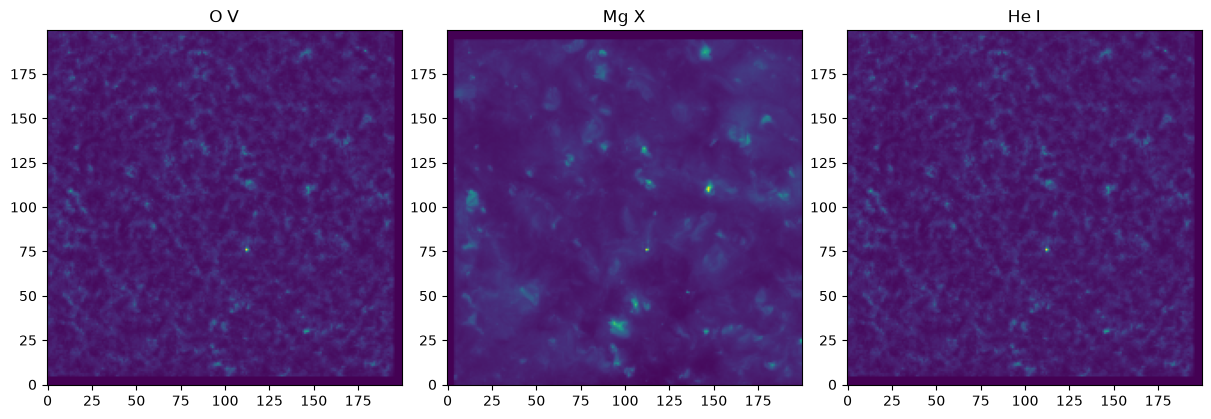

In [6]:
spectral_lines = ["O V", "Mg X", "He I"]

fig, ax = plt.subplots(ncols=3, figsize=(12, 4), constrained_layout=True)
for i in range(3):
    index = dict(wavelength=i, velocity=0)
    ax[i].imshow(scene_fit.outputs[index].ndarray.value.T, origin="lower")
    ax[i].set_title(spectral_lines[i]);

## Model

Start from the hard-coded per-channel best fit and idealize the materials,
so that the modeled counts are not modulated by the wavelength-dependent
coating and filter efficiencies (the correlation merit is insensitive to
per-channel scale factors anyway).

In [7]:
model = esis.flights.f1.optics.distortion_fit(num_distribution=0)

model.grating.material = optika.materials.Mirror()
model.primary_mirror.material = optika.materials.Mirror()
model.filter.material = None
model.camera.sensor.material = optika.sensors.materials.IdealSensorMaterial()

# a single pupil cell is sufficient for distortion mapping
pupil = na.Cartesian2dVectorLinearSpace(
    start=-0.25,
    stop=0.25,
    axis=na.Cartesian2dVectorArray("pupil_x", "pupil_y"),
    num=2,
)

## Starting comparison

Render the model image and compare it against the Level-1 data.

In [8]:
kwargs_image = dict(
    pupil=pupil,
    axis_wavelength="velocity",
    axis_field=("detector_x", "detector_y"),
    noise=False,
)


def render(instrument):
    image = instrument.system.image(scene_fit, **kwargs_image)
    axis_extra = tuple(set(image.outputs.shape) - set(na.shape(l1.outputs)))
    return image.outputs.sum(axis_extra)


image_start = render(model)
image_start.shape

{'channel': 4, 'detector_x': 2048, 'detector_y': 1040}

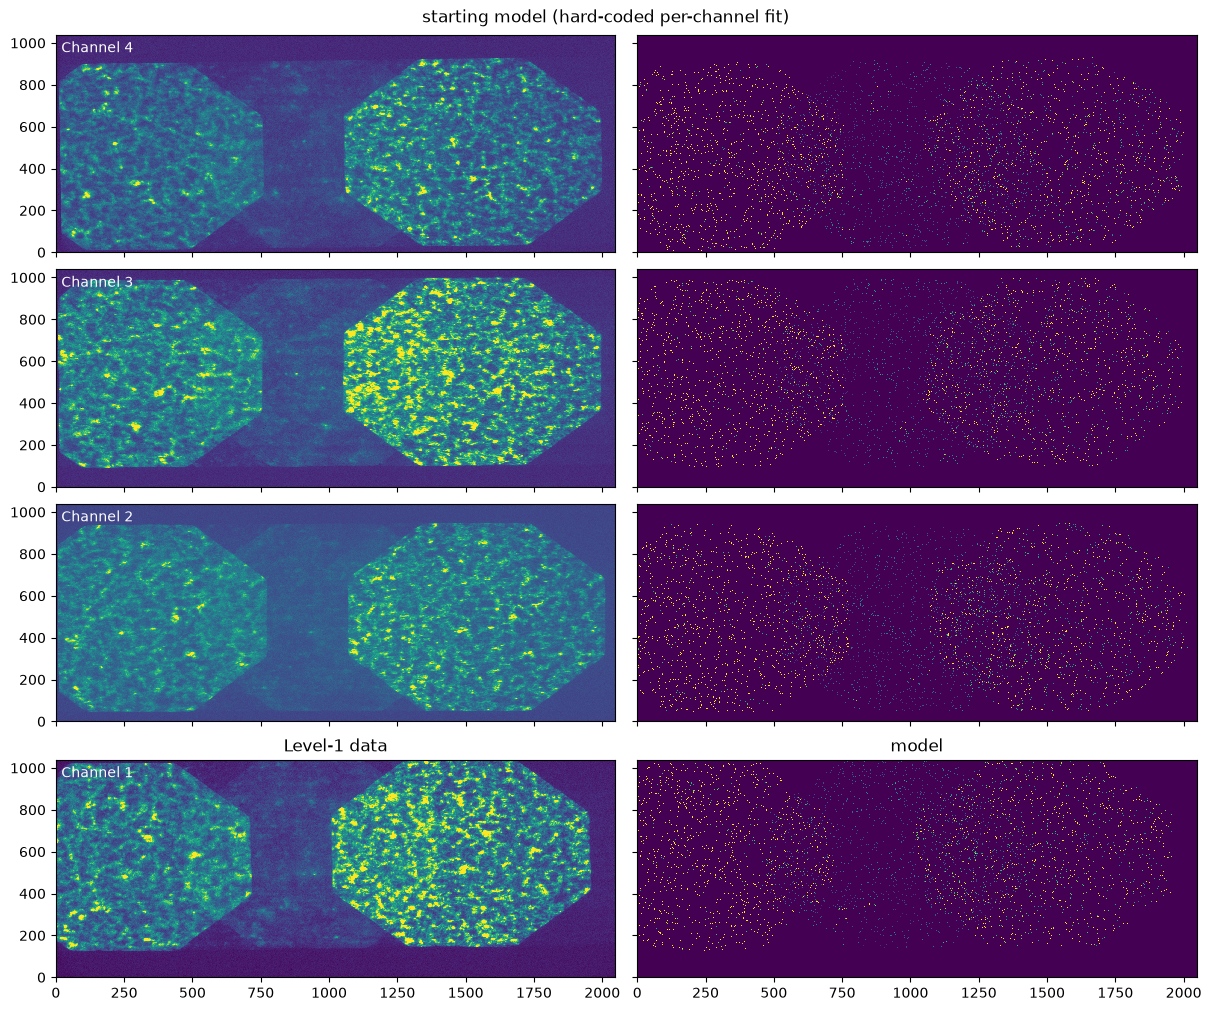

In [9]:
def compare(image_model, title):
    fig, ax = na.plt.subplots(
        figsize=(12, 10),
        constrained_layout=True,
        axis_rows="channel",
        nrows=l1.shape["channel"],
        axis_cols="column",
        ncols=2,
        sharex=True,
        sharey=True,
    )
    fig.suptitle(title)
    data = (l1.outputs - l1.outputs.mean()) / l1.outputs.std()
    na.plt.pcolormesh(
        l1.inputs.pixel.x,
        l1.inputs.pixel.y,
        C=data.value,
        ax=ax[dict(column=0)],
        vmax=np.percentile(data.value, 99),
    )
    image_model = (image_model - image_model.mean()) / image_model.std()
    na.plt.pcolormesh(
        l1.inputs.pixel.x,
        l1.inputs.pixel.y,
        C=image_model.value,
        ax=ax[dict(column=1)],
        vmax=np.percentile(image_model.value, 99),
    )
    na.plt.text(
        x=0.01,
        y=0.97,
        s=l1.channel,
        transform=na.plt.transAxes(ax[dict(column=0)]),
        ax=ax[dict(column=0)],
        ha="left",
        va="top",
        color="white",
    )
    ax.ndarray[0, 0].set_title("Level-1 data")
    ax.ndarray[0, 1].set_title("model")


compare(image_start, "starting model (hard-coded per-channel fit)")

## Coupled parameters

The hard-coded fit lets every parameter vary independently per channel, but
several of them describe a single physical part, so their per-channel scatter
is unphysical:

* `roll_field_stop` — there is only one field stop,
* `displacement_primary` — there is only one primary mirror,
* `pitch`, `yaw`, `roll` — the payload has a single pointing.

Replace those with their channel means to form the coupled starting point.
The per-grating parameters (`yaw_grating`, `pitch_grating`, `roll_grating`,
`spacing_rulings`) remain independent, since each channel has its own
grating. This reduces the fit from 36 to 21 degrees of freedom.

In [10]:
parameters = esis.optics.DistortionParameters.from_instrument(model)

parameters.roll_field_stop = parameters.roll_field_stop.mean()
parameters.displacement_primary = parameters.displacement_primary.mean()
parameters.pitch = parameters.pitch.mean()
parameters.yaw = parameters.yaw.mean()
parameters.roll = parameters.roll.mean()

print("degrees of freedom:", na.pack(parameters).shape["pack"])
parameters

degrees of freedom: 21


DistortionParameters(
    yaw_grating=ScalarArray(
        ndarray=[-269.3, -268.1, -268.7, -268. ] arcmin,
        axes=('channel',),
    ),
    pitch_grating=ScalarArray(
        ndarray=[3.704, 1.522, 1.316, 5.705] arcmin,
        axes=('channel',),
    ),
    roll_grating=ScalarArray(
        ndarray=[1.027 , 0.2393, 0.3678, 1.02  ] deg,
        axes=('channel',),
    ),
    roll_field_stop=ScalarArray(
        ndarray=0.039975 deg,
        axes=(),
    ),
    spacing_rulings=ScalarArray(
        ndarray=[0.3854, 0.3859, 0.3855, 0.3863] um,
        axes=('channel',),
    ),
    displacement_primary=ScalarArray(
        ndarray=-2.5205175 mm,
        axes=(),
    ),
    pitch=ScalarArray(
        ndarray=-21.1986875 arcsec,
        axes=(),
    ),
    yaw=ScalarArray(
        ndarray=-17.152525 arcsec,
        axes=(),
    ),
    roll=ScalarArray(
        ndarray=-0.607845 deg,
        axes=(),
    ),
)

## Polish bounds

Since this is a polish around a known-good starting point, the bounds are
tight absolute windows around the start, sized to comfortably contain the
per-channel scatter of the original fit.

In [11]:
delta = esis.optics.DistortionParameters(
    yaw_grating=2 * u.arcmin,
    pitch_grating=2 * u.arcmin,
    roll_grating=0.25 * u.deg,
    roll_field_stop=1 * u.deg,
    spacing_rulings=5e-4 * u.um,
    displacement_primary=3 * u.mm,
    pitch=15 * u.arcsec,
    yaw=15 * u.arcsec,
    roll=0.5 * u.deg,
)


def shift(parameters, delta, sign):
    return esis.optics.DistortionParameters(**{
        field.name: getattr(parameters, field.name) + sign * getattr(delta, field.name)
        for field in dataclasses.fields(parameters)
    })


bounds = (shift(parameters, delta, -1), shift(parameters, delta, +1))

## How the fit is scored

Each trial parameter set is graded by `esis.optics.DistortionObjective`, which
reproduces the scene through the perturbed instrument and scores the result as

$$\mathrm{merit} = -1000 \cdot \mathrm{correlation}(\mathrm{model}, \mathrm{data}) + \mathrm{penalty}_\mathrm{off\text{-}target}.$$

* **correlation** is the Pearson correlation between the standardized modeled
  and observed images. It rewards getting structure in the *right place* and is
  blind to overall brightness — which is why the idealized materials in the
  Model section are harmless, and why per-channel brightness differences are
  handled by averaging the correlation across channels (`axis_channel`).
* **off-target penalty** is the squared mean ray position, which keeps the
  field from walking off the detector.

Lower is better. The ray trace samples photons randomly, so the merit is
**stochastic even with `noise=False`**; gradient-based optimizers would chase
that noise, so the fit uses a derivative-free global optimizer
(`scipy.optimize.differential_evolution`).

## Coupled polish

Fit all four channels at once. With `axis_channel="channel"` the correlation
merit is computed independently per channel and averaged, so per-channel
brightness differences in the data do not suppress it.

Convergence is logged to a timestamped directory
(`convergence_data.csv`, `full_output.log`, `convergence_plot.png`).

In [12]:
directory = pathlib.Path(
    f"distortion_polish_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)

x0 = na.pack(parameters).ndarray
lower = na.pack(bounds[0]).ndarray
upper = na.pack(bounds[1]).ndarray

if quick:
    rng = np.random.default_rng(42)
    init = lower + (upper - lower) * rng.uniform(size=(5, x0.size))
    init[0] = x0
    kwargs_optimizer = dict(init=init, maxiter=2, tol=1e6, polish=False)
else:
    kwargs_optimizer = dict(
        popsize=10,
        maxiter=200,
        workers=-1,
        updating="deferred",
        polish=True,
    )

fitted = esis.optics.fit_distortion(
    instrument=model,
    scene=scene_fit,
    observation=l1.outputs.value,
    bounds=bounds,
    parameters=parameters,
    pupil=pupil,
    axis_wavelength="velocity",
    axis_field=("detector_x", "detector_y"),
    axis_channel="channel",
    directory=directory,
    kwargs_optimizer=kwargs_optimizer,
)

iteration 001 | energy: -9.338266e+01 | x: [-2.6930e+02, -2.6810e+02, -2.6870e+02, -2.6800e+02,  3.7040e+00,
  1.5220e+00,  1.3160e+00,  5.7050e+00,  1.0270e+00,  2.3930e-01,
  3.6780e-01,  1.0200e+00,  3.9975e-02,  3.8540e-01,  3.8590e-01,
  3.8550e-01,  3.8630e-01, -2.5205e+00, -2.1199e+01, -1.7153e+01,
 -6.0784e-01]


             message: Optimization terminated successfully.
             success: True
                 fun: -93.38265942564819
                   x: [-2.693e+02 -2.681e+02 ... -1.715e+01 -6.078e-01]
                 nit: 1
                nfev: 10
          population: [[-2.693e+02 -2.681e+02 ... -1.715e+01 -6.078e-01]
                       [-2.704e+02 -2.691e+02 ... -1.904e+01 -2.752e-01]
                       ...
                       [-2.682e+02 -2.676e+02 ... -7.732e+00 -9.409e-01]
                       [-2.699e+02 -2.697e+02 ... -3.077e+00 -4.099e-01]]
 population_energies: [-9.338e+01 -3.794e+01 -4.882e+01 -5.174e+01
                       -4.479e+01]
DistortionParameters(
    yaw_grating=ScalarArray(
        ndarray=[-269.3, -268.1, -268.7, -268. ] arcmin,
        axes=('channel',),
    ),
    pitch_grating=ScalarArray(
        ndarray=[3.704, 1.522, 1.316, 5.705] arcmin,
        axes=('channel',),
    ),
    roll_grating=ScalarArray(
        ndarray=[1.027 , 0.2393, 0.3678

In [13]:
fitted

DistortionParameters(
    yaw_grating=ScalarArray(
        ndarray=[-269.3, -268.1, -268.7, -268. ] arcmin,
        axes=('channel',),
    ),
    pitch_grating=ScalarArray(
        ndarray=[3.704, 1.522, 1.316, 5.705] arcmin,
        axes=('channel',),
    ),
    roll_grating=ScalarArray(
        ndarray=[1.027 , 0.2393, 0.3678, 1.02  ] deg,
        axes=('channel',),
    ),
    roll_field_stop=ScalarArray(
        ndarray=0.039975 deg,
        axes=(),
    ),
    spacing_rulings=ScalarArray(
        ndarray=[0.3854, 0.3859, 0.3855, 0.3863] um,
        axes=('channel',),
    ),
    displacement_primary=ScalarArray(
        ndarray=-2.5205175 mm,
        axes=(),
    ),
    pitch=ScalarArray(
        ndarray=-21.1986875 arcsec,
        axes=(),
    ),
    yaw=ScalarArray(
        ndarray=-17.152525 arcsec,
        axes=(),
    ),
    roll=ScalarArray(
        ndarray=-0.607845 deg,
        axes=(),
    ),
)

## Result

The `compare()` plots below put the Level-1 data next to the modeled image for
each channel, and the final cell prints the merit at the coupled starting point
versus after the polish (more negative is a tighter match).

A useful sanity check is that collapsing the shared parameters
(`roll_field_stop`, `displacement_primary`, and the `pitch`/`yaw`/`roll`
pointing) from their per-channel values to a single channel mean barely changes
the merit: the per-channel scatter in those parameters was not really earning
its keep, which confirms that they are genuinely shared and that the 21-degree-
of-freedom coupled model is the honest one to polish from. The demonstration
settings (`quick=True`) only exercise the mechanics in a couple of iterations;
the real improvement comes from the `quick=False` production run.

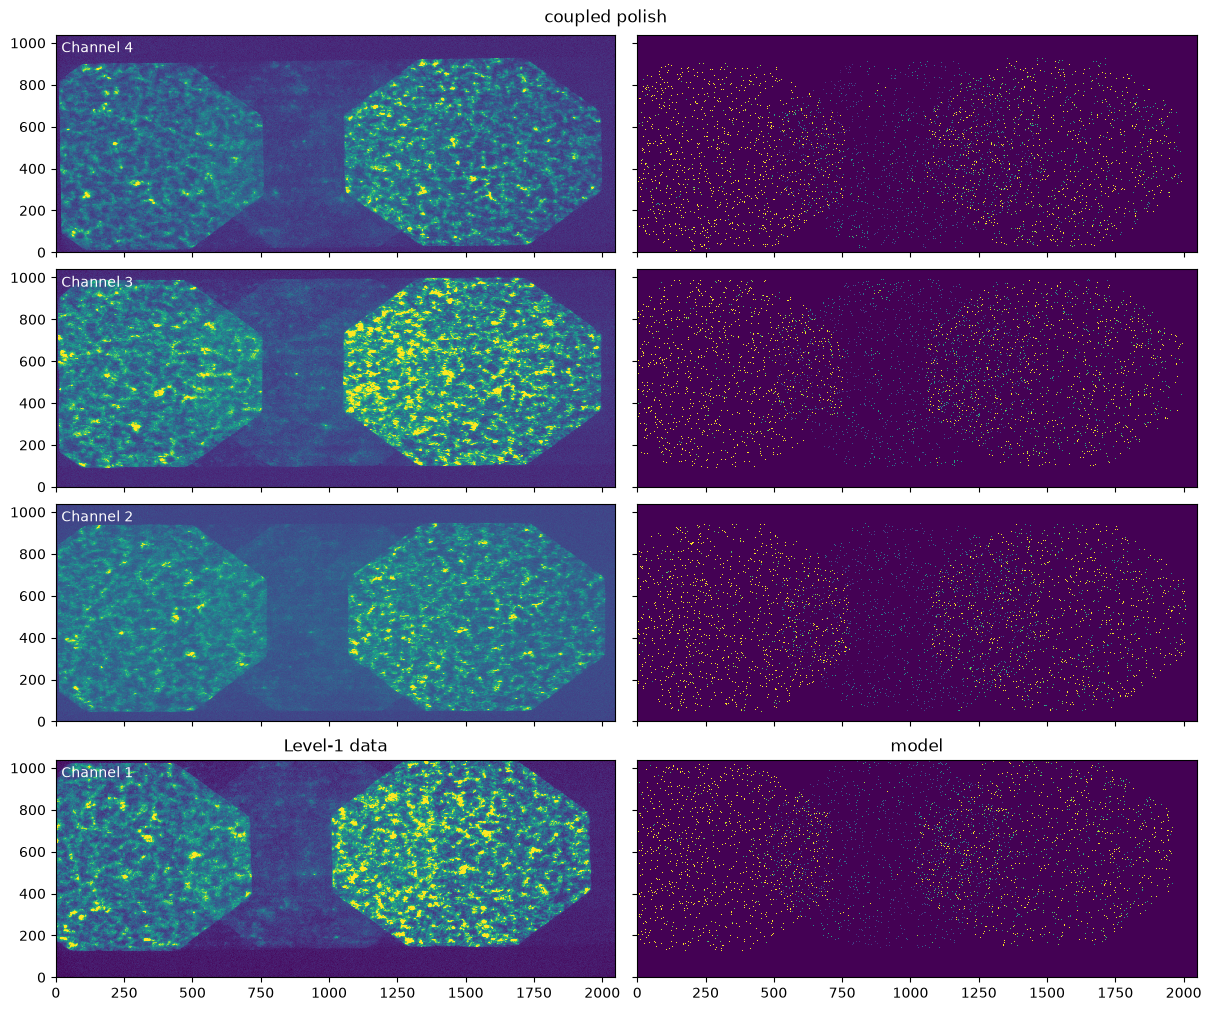

In [14]:
model_fitted = fitted.to_instrument(model)
image_fitted = render(model_fitted)

compare(image_fitted, "coupled polish")

In [15]:
objective = esis.optics.DistortionObjective(
    instrument=model,
    parameters=parameters,
    scene=scene_fit,
    observation=l1.outputs.value,
    pupil=pupil,
    axis_wavelength="velocity",
    axis_field=("detector_x", "detector_y"),
    axis_channel="channel",
)

print("merit at coupled start:", objective(na.pack(parameters).ndarray))
print("merit after polish:    ", objective(na.pack(fitted).ndarray))

merit at coupled start: -93.01488069564134


merit after polish:     -92.99401599800704


## Faster polish (merit scans)

The differential-evolution polish above is robust but slow, because each
evaluation of the merit is stochastic: the imaging model jitters every ray
randomly within its scene cell. Freezing that jitter with a fixed `seed`
makes the merit a deterministic function of the parameters, and convolving
the modeled image with a one-pixel Gaussian point-spread function
(`sigma_psf`) both models the blur of the real optics and makes the sparse
raytraced image respond smoothly to sub-pixel parameter changes.

Even so, the smoothed correlation surface is locally too flat for
derivative-based optimizers: `scipy.optimize.least_squares` was tried and
terminates after moving a tiny fraction of the distance to the peak.
`esis.optics.fit_distortion_scan` instead reads the shape of the merit basin
directly: each parameter is scanned along a coarse-to-fine schedule of
offsets and moved to the peak of its correlation curve, refined with a
parabola. With `axis_channel` given, every channel's peak is read from its
own curve during a single pass of coherent scans, so one scan fits all four
channels at once (here `coherent=True` instead applies one shared offset,
matching the coupled single-payload pointing above). Strongly-coupled pairs
can be scanned jointly by keying a round with a tuple of field names.

This is the engine behind the committed reference and pointing fits; see
`esis.flights.f1.optics.fit_distortion_reference` and
`esis.flights.f1.optics.fit_distortion_pointing` to reproduce them.

In [16]:
grids = [
    dict(
        pitch=np.linspace(-10, 10, 21) * u.arcsec,
        yaw=np.linspace(-10, 10, 21) * u.arcsec,
        roll=np.linspace(-0.4, 0.4, 11) * u.deg,
    ),
    dict(
        pitch=np.linspace(-1, 1, 11) * u.arcsec,
        yaw=np.linspace(-1, 1, 11) * u.arcsec,
        roll=np.linspace(-0.05, 0.05, 11) * u.deg,
    ),
]
if quick:
    grids = [
        dict(
            pitch=np.linspace(-10, 10, 5) * u.arcsec,
            yaw=np.linspace(-10, 10, 5) * u.arcsec,
        ),
    ]

fitted_scan = esis.optics.fit_distortion_scan(
    instrument=model,
    scene=scene_fit,
    observation=l1.outputs.value,
    grids=grids,
    parameters=parameters,
    pupil=pupil,
    axis_wavelength="velocity",
    axis_field=("detector_x", "detector_y"),
    axis_channel="channel",
    coherent=True,
    sigma_psf=1.0,
    directory=pathlib.Path(
        f"distortion_polish_scan_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    ),
)
fitted_scan

DistortionParameters(
    yaw_grating=ScalarArray(
        ndarray=[-269.3, -268.1, -268.7, -268. ] arcmin,
        axes=('channel',),
    ),
    pitch_grating=ScalarArray(
        ndarray=[3.704, 1.522, 1.316, 5.705] arcmin,
        axes=('channel',),
    ),
    roll_grating=ScalarArray(
        ndarray=[1.027 , 0.2393, 0.3678, 1.02  ] deg,
        axes=('channel',),
    ),
    roll_field_stop=ScalarArray(
        ndarray=0.039975 deg,
        axes=(),
    ),
    spacing_rulings=ScalarArray(
        ndarray=[0.3854, 0.3859, 0.3855, 0.3863] um,
        axes=('channel',),
    ),
    displacement_primary=ScalarArray(
        ndarray=-2.5205175 mm,
        axes=(),
    ),
    pitch=ScalarArray(
        ndarray=-21.1986875 arcsec,
        axes=(),
    ),
    yaw=ScalarArray(
        ndarray=-17.152525 arcsec,
        axes=(),
    ),
    roll=ScalarArray(
        ndarray=-0.607845 deg,
        axes=(),
    ),
)

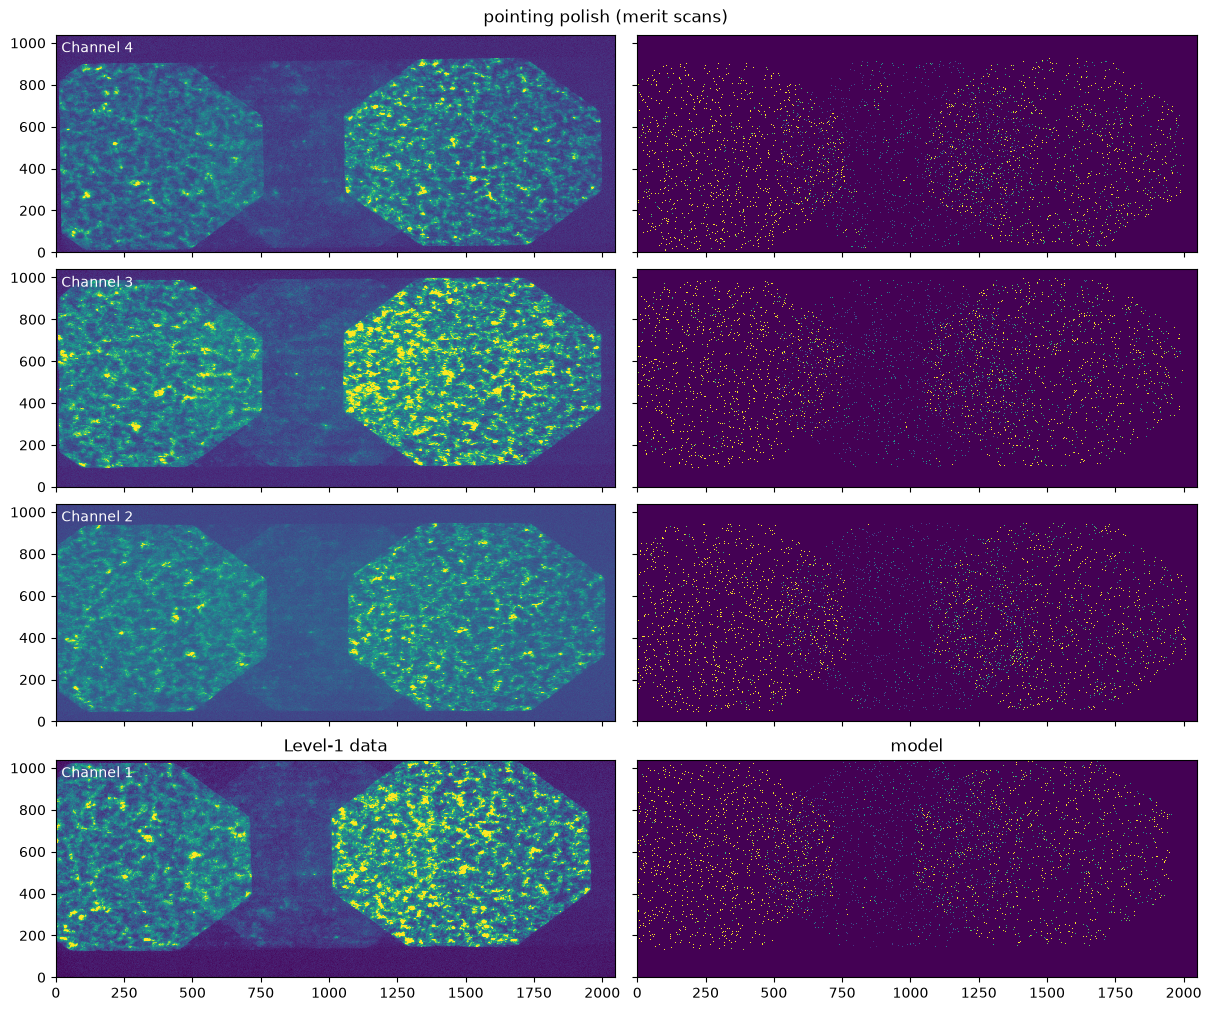

In [17]:
model_scan = fitted_scan.to_instrument(model)
image_scan = render(model_scan)

compare(image_scan, "pointing polish (merit scans)")

In [18]:
print("merit, differential evolution:", objective(na.pack(fitted).ndarray))
print("merit, scans:                  ", objective(na.pack(fitted_scan).ndarray))

merit, differential evolution: -93.63737345132844


merit, scans:                   -93.90780783959342


## The committed result

The production fits made with this machinery are committed to the repository
as plain-text data files, loaded by `esis.flights.f1.optics.distortion_fit`:

* `_data/distortion_reference.ecsv` — the per-channel reference parameters,
* `_data/distortion_pointing.ecsv` — the per-frame payload pointing offsets
  (available via `distortion_fit(axis_time="time")`).

Blinking the fitted model against every Level-1 frame of the flight shows the
quality of the registration as the payload pointing drifts:

![model and data blink comparison](../_static/blink.gif)